### **Nome: Jean Carlos Martins Da Silva Magalhães**

### **Matrícula: 603162**


---



In [210]:
!pip install scipy
!pip install matplotlib
!pip install seaborn

In [211]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import shapiro
from scipy.stats import kstest

## **Questão 1**

### Considere o conjunto de dados disponível em **breastcancer.csv**, organizado em 31 colunas, sendo as 30 primeiras colunas os atributos e a última coluna a saída. Os 30 atributos coletados de exames médicos são usados no diagnóstico do câncer de mama, sendo 1 a classe positiva e 0 a classe negativa. Maiores detalhes sobre os dados podem ser conferidos em **https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset**.

In [212]:
cancer_dataset = np.loadtxt('breastcancer.csv', delimiter=',', skiprows=1)
cancer_dataset

array([[2.057e+01, 1.777e+01, 1.329e+02, ..., 2.750e-01, 8.902e-02,
        1.000e+00],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 3.613e-01, 8.758e-02,
        1.000e+00],
       [1.142e+01, 2.038e+01, 7.758e+01, ..., 6.638e-01, 1.730e-01,
        1.000e+00],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 2.218e-01, 7.820e-02,
        1.000e+00],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 4.087e-01, 1.240e-01,
        1.000e+00],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 2.871e-01, 7.039e-02,
        0.000e+00]])

In [213]:
# Adiciona uma coluna de 1s para o termo de bias
def adicionar_bias(X):
    # Armazena a quantidade de linhas do dataset
    n = X.shape[0]
    # Retorna a matriz X com uma coluna de 1s adicionada
    return np.hstack((np.ones((n, 1)), X))

In [214]:
def normaliza(X):
    # Calculando a média e a distribuição
    mean = X.sum(axis = 0) / X.shape[0]
    std = np.sqrt(((X-mean)**2).sum(axis=0)/(X.shape[0]-1))
    # Normaliza os dados
    return ((X - mean) / std), mean, std

In [215]:
def sigmoid(z):
    # Calcula a função sigmoide
    return 1 / (1 + np.exp(-z))

In [216]:
def kfold(X, y, k):
    # Embaralha os dados
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    # Divide os dados em k folds
    folds = np.array_split(indices, k)

    for i in range(k):
        # Cria os conjuntos de treino e teste
        test_indices = folds[i]
        train_indices = np.concatenate(folds[:i] + folds[i+1:])

        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]

        yield X_train, X_test, y_train, y_test


In [217]:
def predict(theta, X):
    # Faz previsões com base nos parâmetros theta
    probabilidade = sigmoid(X @ theta)
    # Converte as probabilidades em classes
    return (probabilidade >= 0.5).astype(int)

### a) Considerando uma validação cruzada em 10 folds, avalie modelos de classificação binária nos dados em questão. Para tanto, use as abordagens abaixo:


### b) Para cada modelo criado, reporte valor médio e desvio padrão da **acurácia global** e da **acurácia por classe**.



### – **Regressão logística** (treinado com GD ou SGD);

In [218]:
def funcao_custo(theta, X, y):
    # Calcula a função de custo
    m = X.shape[0]
    h = sigmoid(X @ theta)

    # Evita log(0) forçando os valores a ficarem no intervalo (1e-10, 1 - 1e-10)
    epsilon = 1e-6
    h = np.clip(h, epsilon, 1 - epsilon)

    return (-1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))

In [219]:
def gradiente_descendente(theta, X, y, alpha, num_iter):
    # Inicializa o vetor de custos
    custo = np.zeros(num_iter)
    m = X.shape[0]

    for i in range(num_iter):
        # Calcula a função sigmoide
        h = sigmoid(X @ theta)
        # Atualiza os parâmetros theta
        theta -= (alpha/m) * (X.T @ (h - y))
        # Armazena o custo
        custo[i] = funcao_custo(theta, X, y)

    return theta, custo

In [220]:
def cross_validation(X, y, k, alpha, num_iter):
    acuracias_globais = []
    acuracias_por_classe = []
    custos = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza os dados
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Adiciona o bias
        X_train = adicionar_bias(X_train)
        X_test = adicionar_bias(X_test)

         # Inicializa os pesos
        theta = np.zeros(X_train.shape[1])

        # Treina o modelo
        theta, custo = gradiente_descendente(theta, X_train, y_train, alpha, num_iter)

        # Faz previsões
        y_pred = predict(theta, X_test)

        custos.append(custo[-1])

       # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

      # Converte para array para facilitar operações
    acuracias_por_classe = np.array(acuracias_por_classe)

    # Calcula estatísticas
    media_global = np.mean(acuracias_globais)
    desvio_global = np.std(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return np.mean(custos), np.std(custos), media_global, desvio_global, media_por_classe, desvio_por_classe, acuracias_globais

In [221]:
# Separa os dados em variáveis independentes e dependentes
X = cancer_dataset[:, :-1]
y = cancer_dataset[:, -1]

print(X.shape)
print(y.shape)

# Define os parâmetros
alpha = 0.01
num_iter = 1000
k = 10

# Executa a validação cruzada
media_custo, desvio_padrao_custo, media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation(X, y, k, alpha, num_iter)

print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")

print("\n")

print(f'Média do custo: {media_custo}')
print(f'Desvio padrão do custo: {desvio_padrao_custo}')
print(f"Acurácias globais nos folds: {acuracias_globais}")


(568, 30)
(568,)
Acurácia global média: 0.9807
Desvio padrão da acurácia global: 0.0165


Acurácia média e desvio padrão da classe 0: 0.9916 (± 0.0177)
Acurácia média e desvio padrão da classe 1: 0.9628 (± 0.0337)


Acurácia global para o fold 0: 0.9474
Acurácia global para o fold 1: 1.0000
Acurácia global para o fold 2: 0.9649
Acurácia global para o fold 3: 0.9825
Acurácia global para o fold 4: 1.0000
Acurácia global para o fold 5: 0.9825
Acurácia global para o fold 6: 0.9825
Acurácia global para o fold 7: 0.9649
Acurácia global para o fold 8: 0.9821
Acurácia global para o fold 9: 1.0000


Média do custo: 0.1029854060546812
Desvio padrão do custo: 0.003859335695830921
Acurácias globais nos folds: [np.float64(0.9473684210526315), np.float64(1.0), np.float64(0.9649122807017544), np.float64(0.9824561403508771), np.float64(1.0), np.float64(0.9824561403508771), np.float64(0.9824561403508771), np.float64(0.9649122807017544), np.float64(0.9821428571428571), np.float64(1.0)]


### – **Análise do discriminante Gaussiano**;

In [222]:
X = cancer_dataset[:, :-1]
for i in range(X.shape[1]):
    mean = np.mean(X[:, i])
    std = np.std(X[:, i], ddof=1)
    stat, p_value = kstest(X[:, i], 'norm', args=(mean, std))
    print(f"Feature {i}: p = {p_value:.4f} - {'Normal' if p_value > 0.05 else 'Não normal'}")

Feature 0: p = 0.0000 - Não normal
Feature 1: p = 0.1161 - Normal
Feature 2: p = 0.0000 - Não normal
Feature 3: p = 0.0000 - Não normal
Feature 4: p = 0.4498 - Normal
Feature 5: p = 0.0000 - Não normal
Feature 6: p = 0.0000 - Não normal
Feature 7: p = 0.0000 - Não normal
Feature 8: p = 0.1002 - Normal
Feature 9: p = 0.0001 - Não normal
Feature 10: p = 0.0000 - Não normal
Feature 11: p = 0.0002 - Não normal
Feature 12: p = 0.0000 - Não normal
Feature 13: p = 0.0000 - Não normal
Feature 14: p = 0.0000 - Não normal
Feature 15: p = 0.0000 - Não normal
Feature 16: p = 0.0000 - Não normal
Feature 17: p = 0.0011 - Não normal
Feature 18: p = 0.0000 - Não normal
Feature 19: p = 0.0000 - Não normal
Feature 20: p = 0.0000 - Não normal
Feature 21: p = 0.2846 - Normal
Feature 22: p = 0.0000 - Não normal
Feature 23: p = 0.0000 - Não normal
Feature 24: p = 0.4493 - Normal
Feature 25: p = 0.0000 - Não normal
Feature 26: p = 0.0000 - Não normal
Feature 27: p = 0.0001 - Não normal
Feature 28: p = 0.0002

In [223]:
# Análise do discriminante Gaussiano
def gaussian_discriminant_analysis(X, y):
    classes = np.unique(y)

    X0 = X[y == classes[0]]
    X1 = X[y == classes[1]]

    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    phi = X1.shape[0] / X.shape[0]

    sigma = np.zeros((X.shape[1], X.shape[1]))
    for x in X0:
        diff = x - mu0
        sigma += np.outer(diff, diff)
    for x in X1:
        diff = x - mu1
        sigma += np.outer(diff, diff)

    sigma /= X.shape[0]
    sigma += 1e-6 * np.eye(X.shape[1])

    sigma_inv = np.linalg.inv(sigma)

    theta = sigma_inv @ (mu1 - mu0)
    theta0 = (
        -0.5 * mu1.T @ sigma_inv @ mu1
        + 0.5 * mu0.T @ sigma_inv @ mu0
        + np.log(phi / (1 - phi))
    )

    return np.concatenate(([theta0], theta))

In [224]:
# Validação cruzada para GDA
def cross_validation_gda(X, y, k):
    acuracias_globais = []
    acuracias_por_classe = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza com base no treino
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Treina o modelo SEM bias
        theta = gaussian_discriminant_analysis(X_train, y_train)

        # Adiciona bias só na predição
        X_test_bias = adicionar_bias(X_test)

        # Faz previsões
        y_pred = predict(theta, X_test_bias)

        # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

    acuracias_por_classe = np.array(acuracias_por_classe)

    media_global = np.mean(acuracias_globais)
    desvio_global = np.std(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return media_global, desvio_global, media_por_classe, desvio_por_classe, acuracias_globais

In [225]:
# Separa os dados em variáveis independentes e dependentes
X = cancer_dataset[:, :-1]
y = cancer_dataset[:, -1]

# Define os parâmetros
k = 10

# Executa a validação cruzada
media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation_gda(X, y, k)

print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")


Acurácia global média: 0.9578
Desvio padrão da acurácia global: 0.0262


Acurácia média e desvio padrão da classe 0: 0.9945 (± 0.0110)
Acurácia média e desvio padrão da classe 1: 0.8998 (± 0.0686)


Acurácia global para o fold 0: 0.9123
Acurácia global para o fold 1: 0.9474
Acurácia global para o fold 2: 0.9123
Acurácia global para o fold 3: 0.9649
Acurácia global para o fold 4: 0.9825
Acurácia global para o fold 5: 0.9474
Acurácia global para o fold 6: 0.9649
Acurácia global para o fold 7: 0.9825
Acurácia global para o fold 8: 0.9821
Acurácia global para o fold 9: 0.9821


### – **Naive Bayes Gaussiano**;

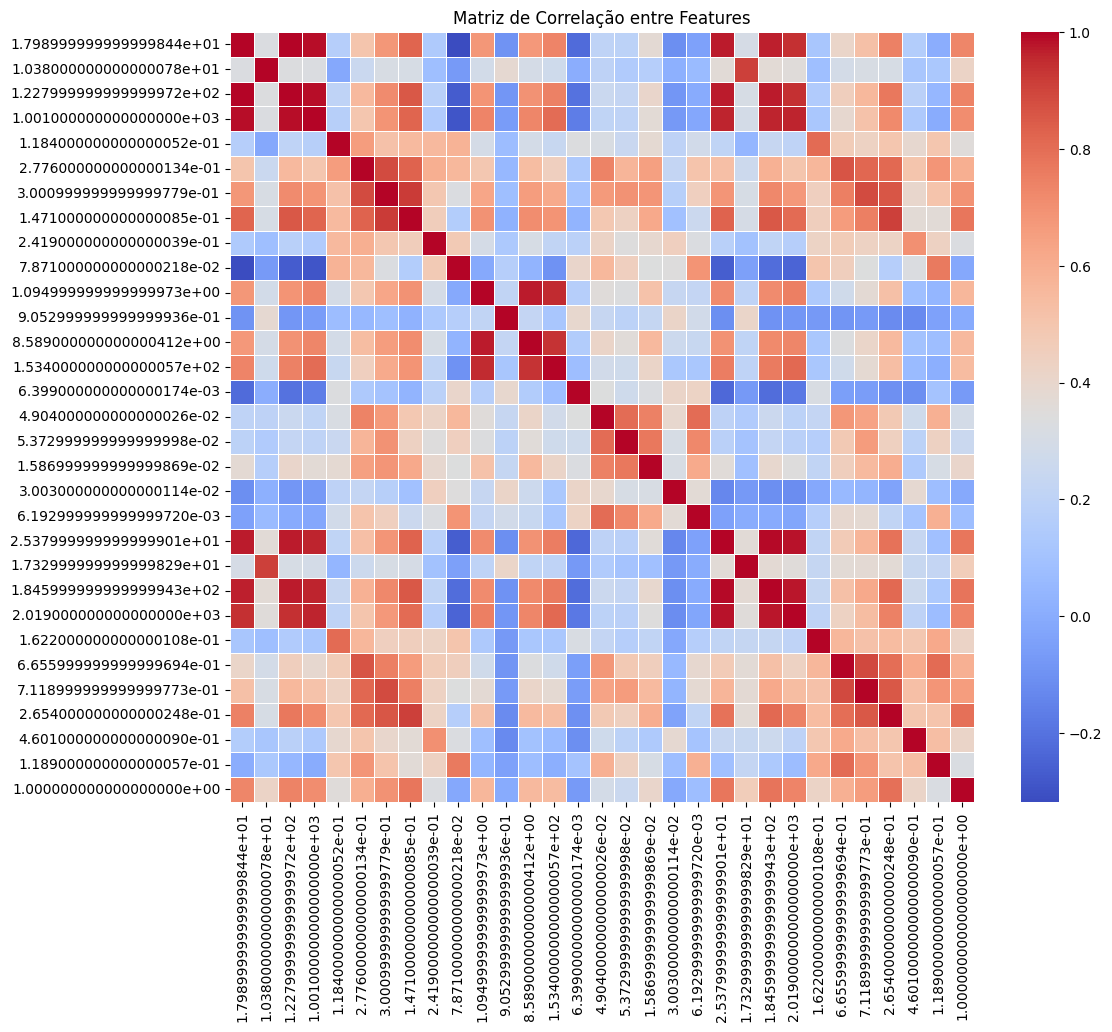

In [226]:
df = pd.read_csv('breastcancer.csv')

# Calcula a matriz de correlação
correlation_matrix = df.corr()

# Exibe como heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação entre Features")
plt.show()

In [227]:
# Extrai pares com correlação alta (mas diferentes de 1)
threshold = 0.8
corr_pairs = correlation_matrix.abs().unstack()
high_corr = corr_pairs[(corr_pairs > threshold) & (corr_pairs < 1)].sort_values(ascending=False)

print("Pares com correlação alta:")
print(high_corr)

Pares com correlação alta:
1.798999999999999844e+01  1.227999999999999972e+02    0.997876
1.227999999999999972e+02  1.798999999999999844e+01    0.997876
2.537999999999999901e+01  1.845999999999999943e+02    0.993814
1.845999999999999943e+02  2.537999999999999901e+01    0.993814
1.001000000000000000e+03  1.798999999999999844e+01    0.987344
                                                        ...   
4.904000000000000026e-02  6.192999999999999720e-03    0.802973
                          5.372999999999999998e-02    0.801183
5.372999999999999998e-02  4.904000000000000026e-02    0.801183
1.001000000000000000e+03  1.534000000000000057e+02    0.800829
1.534000000000000057e+02  1.001000000000000000e+03    0.800829
Length: 86, dtype: float64


In [228]:
# Naive Bayes Gaussiano binário
def gaussian_naive_bayes(X, y):
    classes = np.unique(y)

    priors = {}
    means = {}
    variances = {}

    for c in classes:
        X_c = X[y == c]
        priors[c] = X_c.shape[0] / X.shape[0]
        means[c] = np.mean(X_c, axis=0)
        variances[c] = np.var(X_c, axis=0) + 1e-9

    return priors, means, variances

In [229]:
def predict_gaussian_naive_bayes(X, priors, means, variances):
    classes = sorted(priors.keys())
    posteriors = np.zeros((X.shape[0], len(classes)))

    for i, c in enumerate(classes):
        prior = priors[c]
        mean = means[c]
        variance = variances[c]

        log_likelihood = -0.5 * np.sum(
            np.log(2 * np.pi * variance) + ((X - mean) ** 2) / variance,
            axis=1
        )
        log_posterior = np.log(prior) + log_likelihood
        posteriors[:, i] = log_posterior

    return np.array([classes[i] for i in np.argmax(posteriors, axis=1)])

In [230]:
# Cross-validation para Naive Bayes
def cross_validation_naive_bayes(X, y, k):
    acuracias_globais = []
    acuracias_por_classe = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza com base no treino
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Treina o modelo SEM bias
        priors, means, variances = gaussian_naive_bayes(X_train, y_train)

        # Faz previsões
        y_pred = predict_gaussian_naive_bayes(X_test, priors, means, variances)

        # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

    acuracias_por_classe = np.array(acuracias_por_classe)

    media_global = np.mean(acuracias_globais)
    desvio_global = np.std(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return media_global, desvio_global, media_por_classe, desvio_por_classe, acuracias_globais

In [231]:
# Separa os dados em variáveis independentes e dependentes
X = cancer_dataset[:, :-1]
y = cancer_dataset[:, -1]

# Define os parâmetros
k = 10

# Executa a validação cruzada naive bayes
media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation_naive_bayes(X, y, k)

print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")

Acurácia global média: 0.9331
Desvio padrão da acurácia global: 0.0219


Acurácia média e desvio padrão da classe 0: 0.9543 (± 0.0440)
Acurácia média e desvio padrão da classe 1: 0.8966 (± 0.0452)


Acurácia global para o fold 0: 0.8947
Acurácia global para o fold 1: 0.9649
Acurácia global para o fold 2: 0.8947
Acurácia global para o fold 3: 0.9298
Acurácia global para o fold 4: 0.9474
Acurácia global para o fold 5: 0.9474
Acurácia global para o fold 6: 0.9474
Acurácia global para o fold 7: 0.9298
Acurácia global para o fold 8: 0.9464
Acurácia global para o fold 9: 0.9286


## **Questão 2**

### Considere o conjunto de dados disponível em **vehicle.csv**, organizado em 19 colunas, sendo as 18 primeiras colunas os atributos e a última coluna a saída. Os 18 atributos caracterizam a silhueta de veículos, extraídos pelo método HIPS (Hierarchical Image Processing System). A tarefa consiste em classificar o veículo em 4 classes (bus, opel, saab, e van). Maiores detalhes sobre os dados podem ser conferidos em **https://www.openml.org/search?type=data&sort=runs&id=54.**


In [232]:
veiculo_dataset = np.loadtxt('vehicle.csv', delimiter=',', skiprows=1)
veiculo_dataset

array([[ 91.,  41.,  84., ..., 189., 199.,   3.],
       [104.,  50., 106., ..., 188., 196.,   2.],
       [ 93.,  41.,  82., ..., 199., 207.,   3.],
       ...,
       [106.,  54., 101., ..., 187., 201.,   2.],
       [ 86.,  36.,  78., ..., 190., 195.,   2.],
       [ 85.,  36.,  66., ..., 186., 190.,   3.]])

In [233]:
# Softmax
def softmax(z):
    # Calcula a função softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [234]:
# Predict multiclass
def predict_multiclass(theta, X):
    # Faz previsões com base nos parâmetros theta
    probabilidade = softmax(X @ theta)
    # Converte as probabilidades em classes
    return np.argmax(probabilidade, axis=1)

In [235]:
# one-hot encoding
def one_hot_encoding(y):
    y = y.astype(int)
    mat = np.zeros((y.size, y.max() + 1))
    mat[np.arange(y.size), y] = 1
    return mat

### a) Considerando uma validação cruzada em 10 *folds*, avalie modelos de classificação binária nos dados em questão. Para tanto, use as abordagens abaixo:


### b) Para cada modelo criado, reporte valor médio e desvio padrão da **acurácia global** e da **acurácia por classe**.



### – **Regressão softmax** (treinado com GD ou SGD);

In [236]:
# Funcao de custo multiclass
def funcao_custo_multiclass(theta, X, y):
    # Calcula a função de custo

    m = X.shape[0]
    h = softmax(X @ theta)

    # Evita log(0) forçando os valores a ficarem no intervalo (1e-10, 1 -
    # 1e-10)
    epsilon = 1e-6
    h = np.clip(h, epsilon, 1 - epsilon)

    return (-1/m) * (y.T @ np.log(h))

In [237]:
# Gradiente descendente multiclass
def gradiente_descendente_multiclass(theta, X, y, alpha, num_iter):
    # Inicializa o vetor de custos
    custo = np.zeros(num_iter)
    m = X.shape[0]

    for i in range(num_iter):
        # Calcula a função softmax
        h = softmax(X @ theta)
        # Atualiza os parâmetros theta
        theta -= (alpha/m) * (X.T @ (h - y))
        # Armazena o custo
        custo[i] = np.mean(funcao_custo_multiclass(theta, X, y))

    return theta, custo

In [238]:
# Cross-validation para softmax
def cross_validation_softmax(X, y, k, alpha, num_iter):
    acuracias_globais = []
    acuracias_por_classe = []
    custos = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza os dados
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Adiciona o bias
        X_train = adicionar_bias(X_train)
        X_test = adicionar_bias(X_test)

         # Inicializa os pesos
        theta = np.zeros((X_train.shape[1], len(np.unique(y))))

        # Treina o modelo
        theta, custo = gradiente_descendente_multiclass(theta=theta, X=X_train, y=one_hot_encoding(y_train), alpha=alpha, num_iter=num_iter)

        # Faz previsões
        y_pred = predict_multiclass(theta, X_test)

        custos.append(custo[-1])

       # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

      # Converte para array para facilitar operações
    acuracias_por_classe = np.array(acuracias_por_classe)

    # Calcula estatísticas
    media_global = np.mean(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return np.mean(custos), np.std(custos), media_global, np.std(acuracias_globais), media_por_classe, desvio_por_classe, acuracias_globais

In [239]:
# Separa os dados em variáveis independentes e dependentes
X = veiculo_dataset[:, :-1]
y = veiculo_dataset[:, -1]


# Define os parâmetros
alpha = 0.01
num_iter = 1000
k = 10

# Executa a validação cruzada
media_custo, desvio_padrao_custo, media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation_softmax(X, y, k, alpha, num_iter)
print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")

Acurácia global média: 0.6922
Desvio padrão da acurácia global: 0.0496


Acurácia média e desvio padrão da classe 0: 0.8836 (± 0.0852)
Acurácia média e desvio padrão da classe 1: 0.4328 (± 0.1171)
Acurácia média e desvio padrão da classe 2: 0.4998 (± 0.1033)
Acurácia média e desvio padrão da classe 3: 0.9743 (± 0.0350)


Acurácia global para o fold 0: 0.6471
Acurácia global para o fold 1: 0.7294
Acurácia global para o fold 2: 0.7294
Acurácia global para o fold 3: 0.6235
Acurácia global para o fold 4: 0.7882
Acurácia global para o fold 5: 0.6667
Acurácia global para o fold 6: 0.6786
Acurácia global para o fold 7: 0.7262
Acurácia global para o fold 8: 0.7024
Acurácia global para o fold 9: 0.6310


### – **Análise do discriminante Gaussiano**;


In [240]:
X = veiculo_dataset[:, :-1]
for i in range(X.shape[1]):
    mean = np.mean(X[:, i])
    std = np.std(X[:, i], ddof=1)
    stat, p_value = kstest(X[:, i], 'norm', args=(mean, std))
    print(f"Feature {i}: p = {p_value:.4f} - {'Normal' if p_value > 0.05 else 'Não normal'}")

Feature 0: p = 0.0000 - Não normal
Feature 1: p = 0.0002 - Não normal
Feature 2: p = 0.0000 - Não normal
Feature 3: p = 0.0099 - Não normal
Feature 4: p = 0.0000 - Não normal
Feature 5: p = 0.0000 - Não normal
Feature 6: p = 0.0000 - Não normal
Feature 7: p = 0.0000 - Não normal
Feature 8: p = 0.0000 - Não normal
Feature 9: p = 0.0000 - Não normal
Feature 10: p = 0.0000 - Não normal
Feature 11: p = 0.0000 - Não normal
Feature 12: p = 0.0821 - Normal
Feature 13: p = 0.0000 - Não normal
Feature 14: p = 0.0000 - Não normal
Feature 15: p = 0.0000 - Não normal
Feature 16: p = 0.0009 - Não normal
Feature 17: p = 0.0000 - Não normal


In [241]:

def predict_gda_multiclass(theta, X):
    # Calcula o score linear para cada classe
    scores = X @ theta.T  # (n_amostras x n_classes)

    # Retorna a classe com maior score
    return np.argmax(scores, axis=1)

In [242]:
# Função para treinar o modelo GDA multiclasse
def gaussian_discriminant_analysis_multiclass(X, y):
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]
    theta = []

    mu = []
    phi = []
    for c in classes:
        X_c = X[y == c]
        mu_c = np.mean(X_c, axis=0)
        mu.append(mu_c)
        phi.append(X_c.shape[0] / X.shape[0])
    mu = np.array(mu)
    phi = np.array(phi)

    sigma = np.zeros((n_features, n_features))
    for i, c in enumerate(classes):
        X_c = X[y == c]
        diff = X_c - mu[i]
        sigma += diff.T @ diff
    sigma /= X.shape[0]
    epsilon = 1e-6
    sigma += epsilon * np.eye(sigma.shape[0])
    sigma_inv = np.linalg.inv(sigma)

    for i in range(n_classes):
        theta_i = sigma_inv @ mu[i]
        bias = -0.5 * mu[i].T @ sigma_inv @ mu[i] + np.log(phi[i])
        theta_i = np.concatenate(([bias], theta_i)) # adiciona bias corretamente
        theta.append(theta_i)

    return np.array(theta)

In [243]:
# Cross-validation para GDA multiclass
def cross_validation_gda_multiclass(X, y, k):
    acuracias_globais = []
    acuracias_por_classe = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza com base no treino
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Treina SEM bias
        theta = gaussian_discriminant_analysis_multiclass(X_train, y_train)

        # Adiciona bias só no teste para bater com theta
        X_test = adicionar_bias(X_test)

        # Faz previsões
        y_pred = predict_gda_multiclass(theta, X_test)

        # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

    acuracias_por_classe = np.array(acuracias_por_classe)

    media_global = np.mean(acuracias_globais)
    desvio_global = np.std(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return media_global, desvio_global, media_por_classe, desvio_por_classe, acuracias_globais

In [244]:
# Separa os dados em variáveis independentes e dependentes
X = veiculo_dataset[:, :-1]
y = veiculo_dataset[:, -1]

# Define os parâmetros
k = 10

# Executa a validação cruzada
media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation_gda_multiclass(X, y, k)
print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")

Acurácia global média: 0.7764
Desvio padrão da acurácia global: 0.0307


Acurácia média e desvio padrão da classe 0: 0.9591 (± 0.0380)
Acurácia média e desvio padrão da classe 1: 0.5988 (± 0.0850)
Acurácia média e desvio padrão da classe 2: 0.6021 (± 0.0746)
Acurácia média e desvio padrão da classe 3: 0.9589 (± 0.0387)


Acurácia global para o fold 0: 0.7529
Acurácia global para o fold 1: 0.8118
Acurácia global para o fold 2: 0.8118
Acurácia global para o fold 3: 0.7294
Acurácia global para o fold 4: 0.7412
Acurácia global para o fold 5: 0.7738
Acurácia global para o fold 6: 0.8214
Acurácia global para o fold 7: 0.7500
Acurácia global para o fold 8: 0.7857
Acurácia global para o fold 9: 0.7857


### – **Naive Bayes Gaussiano**;

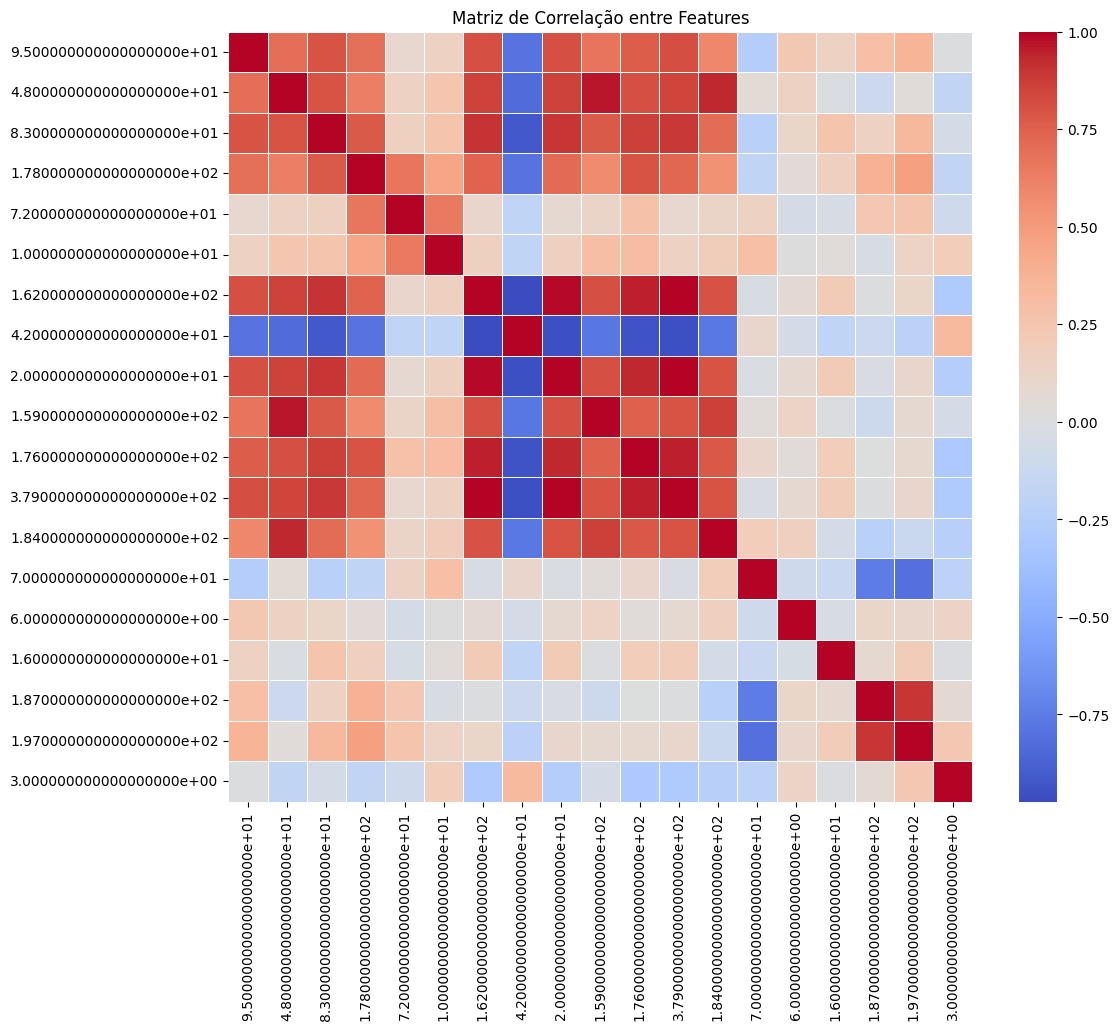

In [245]:
df = pd.read_csv('vehicle.csv')

# Calcula a matriz de correlação
correlation_matrix = df.corr()

# Exibe como heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação entre Features")
plt.show()

In [246]:
# Extrai pares com correlação alta (mas diferentes de 1)
threshold = 0.8
corr_pairs = correlation_matrix.abs().unstack()
high_corr = corr_pairs[(corr_pairs > threshold) & (corr_pairs < 1)].sort_values(ascending=False)

print("Pares com correlação alta:")
print(high_corr)

Pares com correlação alta:
1.620000000000000000e+02  3.790000000000000000e+02    0.996329
3.790000000000000000e+02  1.620000000000000000e+02    0.996329
2.000000000000000000e+01  3.790000000000000000e+02    0.992354
3.790000000000000000e+02  2.000000000000000000e+01    0.992354
2.000000000000000000e+01  1.620000000000000000e+02    0.992088
                                                        ...   
4.800000000000000000e+01  1.760000000000000000e+02    0.808940
1.970000000000000000e+02  7.000000000000000000e+01    0.805395
7.000000000000000000e+01  1.970000000000000000e+02    0.805395
1.620000000000000000e+02  1.840000000000000000e+02    0.801060
1.840000000000000000e+02  1.620000000000000000e+02    0.801060
Length: 62, dtype: float64


In [247]:
# Treina modelo Naive Bayes multiclasse
def train_naive_bayes_gaussian(X, y):
    classes = np.unique(y)

    priors = {}       # Probabilidades a priori P(y=c)
    means = {}        # Médias por classe e feature
    variances = {}    # Variâncias por classe e feature

    for c in classes:
        X_c = X[y == c]
        priors[c] = X_c.shape[0] / X.shape[0]
        means[c] = np.mean(X_c, axis=0)
        variances[c] = np.var(X_c, axis=0) + 1e-9  # Evita divisão por zero

    return priors, means, variances

In [248]:
# Predição com Naive Bayes
def predict_naive_bayes_gaussian(X, priors, means, variances):
    n_samples = X.shape[0]
    n_classes = len(priors)
    posteriors = np.zeros((n_samples, n_classes))

    for c in range(n_classes):
        prior = priors[c]
        mean = means[c]
        variance = variances[c]

        # Calcula a probabilidade de cada amostra pertencer à classe c
        likelihood = np.exp(-0.5 * ((X - mean) ** 2) / variance) / np.sqrt(2 * np.pi * variance)
        posterior = prior * np.prod(likelihood, axis=1)
        posteriors[:, c] = posterior

    return np.argmax(posteriors, axis=1)

In [249]:
# Cross-validation naive bayes multiclass
def cross_validation_naive_bayes_multiclass(X, y, k):
    acuracias_globais = []
    acuracias_por_classe = []

    for X_train, X_test, y_train, y_test in kfold(X, y, k):

        # Normaliza com base no treino
        X_train, mean, std = normaliza(X_train)
        X_test = (X_test - mean) / std

        # Treina o modelo
        priors, means, variances = train_naive_bayes_gaussian(X_train, y_train)

        # Faz previsões
        y_pred = predict_naive_bayes_gaussian(X_test, priors, means, variances)

        # Acurácia global
        acuracia_global = np.mean(y_pred == y_test)
        acuracias_globais.append(acuracia_global)

        # Acurácia por classe
        classes = np.unique(y)
        acuracias_classe = []
        for c in classes:
            idx = (y_test == c)
            acuracia_c = np.mean(y_pred[idx] == y_test[idx])
            acuracias_classe.append(acuracia_c)
        acuracias_por_classe.append(acuracias_classe)

    acuracias_por_classe = np.array(acuracias_por_classe)

    media_global = np.mean(acuracias_globais)
    desvio_global = np.std(acuracias_globais)

    media_por_classe = np.mean(acuracias_por_classe, axis=0)
    desvio_por_classe = np.std(acuracias_por_classe, axis=0)

    return media_global, desvio_global, media_por_classe, desvio_por_classe, acuracias_globais

In [250]:
# Separa os dados em variáveis independentes e dependentes
X = veiculo_dataset[:, :-1]
y = veiculo_dataset[:, -1]

# Define os parâmetros
k = 10

# Executa a validação cruzada
media_g, desvio_g, media_classe, desvio_classe, acuracias_globais = cross_validation_naive_bayes_multiclass(X, y, k)

print(f"Acurácia global média: {media_g:.4f}")
print(f"Desvio padrão da acurácia global: {desvio_g:.4f}")

print("\n")

for i, (m, d) in enumerate(zip(media_classe, desvio_classe)):
    print(f"Acurácia média e desvio padrão da classe {i}: {m:.4f} (± {d:.4f})")

print("\n")

for i, acuracia in enumerate(acuracias_globais):
    print(f"Acurácia global para o fold {i}: {acuracia:.4f}")

Acurácia global média: 0.4510
Desvio padrão da acurácia global: 0.0481


Acurácia média e desvio padrão da classe 0: 0.1664 (± 0.0467)
Acurácia média e desvio padrão da classe 1: 0.4066 (± 0.0672)
Acurácia média e desvio padrão da classe 2: 0.3872 (± 0.1266)
Acurácia média e desvio padrão da classe 3: 0.8809 (± 0.0372)


Acurácia global para o fold 0: 0.4588
Acurácia global para o fold 1: 0.4941
Acurácia global para o fold 2: 0.4118
Acurácia global para o fold 3: 0.3529
Acurácia global para o fold 4: 0.4471
Acurácia global para o fold 5: 0.5476
Acurácia global para o fold 6: 0.4524
Acurácia global para o fold 7: 0.4524
Acurácia global para o fold 8: 0.4643
Acurácia global para o fold 9: 0.4286
